In [7]:


import os

In [8]:
from langgraph.graph import MessagesState,StateGraph, END, START
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_community.tools import DuckDuckGoSearchRun
from langgraph.prebuilt import tools_condition # this is the checker for the if you got a tool back
from langgraph.prebuilt import ToolNode
from IPython.display import Image, display
from typing import Annotated, TypedDict
import operator
from langchain_core.messages import AnyMessage
from langgraph.graph.message import add_messages
from langgraph.prebuilt import tools_condition # this is the checker for the
from langgraph.prebuilt import ToolNode

In [23]:
from langchain_groq import ChatGroq

llm = ChatGroq(model_name="llama-3.3-70b-versatile")
llm.invoke("hi").content

"It's nice to meet you. Is there something I can help you with or would you like to chat?"

In [24]:

def multiply(a: int, b: int) -> int:
    """
    Multiply a and b.
    Args:
        a: first int
        b: second int
    """
    return a * b

In [25]:

def add(a: int, b: int) -> int:
    """Adds a and b.

    Args:
        a: first int
        b: second int
    """
    return a + b

In [26]:

def divide(a: int, b: int) -> float:
    """Divide a and b.

    Args:
        a: first int
        b: second int
    """
    return a / b

In [27]:
divide(10, 2)

5.0

In [28]:
from langchain_community.tools.tavily_search import TavilySearchResults
search = TavilySearchResults()
search.invoke("What is the capital of France?")
     

[{'url': 'https://study.com/academy/lesson/facts-about-france-location-population-history.html',
  'content': "Lesson Summary --------------\n\nFranceis a Western European country. Its capital is Paris, which is well-known for various important sites such as the Eiffel Tower, the Arc de Triomphe, and the Louvre. It has a population of roughly 68 million. France is well-known for its hexagonal shape, but in actuality, several lands outside of Europe are part of France, including French Guiana and French Polynesia. [...] is spoken by many more millions of people across the world. France was once ruled by Napoleon Bonaparte. Napoleon successfully waged war against a coalition of other major European powers for many years.\n\nCreate an account\n\nLessonQuizCourse\n\nQuizCourse5.6K views\n\nThe Country of France ---------------------\n\nFrance is a large European country. The capital of France is Paris, a well-known city. France is very culturally influential. As an example of that cultural

In [29]:

tools = [add, multiply, divide, search]

In [30]:

llm_with_tools=llm.bind_tools(tools)

In [31]:


# System message
sys_msg = SystemMessage(content="You are a helpful assistant tasked with using search and performing arithmetic on a set of inputs.")

In [32]:

def reasoner(state: MessagesState):
   return {"messages": [llm_with_tools.invoke([sys_msg] + state["messages"])]}

In [33]:
# Graph
builder = StateGraph(MessagesState)

# Add nodes
builder.add_node("reasoner", reasoner)

builder.add_node("tools", ToolNode(tools)) # for the tools

# Add edges
builder.add_edge(START, "reasoner")

builder.add_conditional_edges(
    "reasoner",
    # If the latest message (result) from node reasoner is a tool call -> tools_condition routes to tools
    # If the latest message (result) from node reasoner is a not a tool call -> tools_condition routes to END
    tools_condition,
)

builder.add_edge("tools", "reasoner")
react_graph = builder.compile()

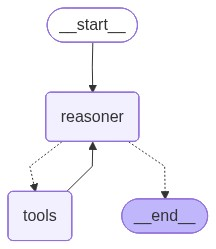

In [34]:

# Display the graph
display(Image(react_graph.get_graph(xray=True).draw_mermaid_png()))
     

In [38]:

messages = [HumanMessage(content="What is 2 times of narendramodi's age?")]

In [39]:

result = react_graph.invoke({"messages": [HumanMessage(content="What is 2 times of narendramodi's age?")]})

# Print final answer
print(result["messages"][-1].content)

The current age of Narendra Modi is 75. 2 times of Narendra Modi's age is 150.


In [40]:

messages = [HumanMessage(content="What is 2 times of narendramodi's age?")]


messages = react_graph.invoke({"messages": messages})

for m in messages['messages']:
    m.pretty_print()
     

================================ Human Message =================================

What is 2 times of narendramodi's age?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (qwzjc1e3k)
 Call ID: qwzjc1e3k
  Args:
    query: Narendra Modi age
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://pwonlyias.com/narendra-modi/", "content": "## PM Narendra Modi Age 2025\n\nNarendra Modi, the present serving Prime Minister of India, was born on September 17, 1950. At present, in 2025, Narendra Modi’s age is 75 on his birthday, September 17, 2025. Throughout his political career, Modi has been a significant figure, known for his leadership, vision, and constructive policies. His journey from humble beginnings to the highest office in the country has been marked by both praise and criticism, shaping the political landscape of India.\n\n## Narendra

In [41]:

messages = [HumanMessage(content="What is the result when you add 100 years to the current age of Elon Musk?")]
     

In [42]:

messages = react_graph.invoke({"messages": messages})

In [43]:

for m in messages['messages']:
    m.pretty_print()
     

================================ Human Message =================================

What is the result when you add 100 years to the current age of Elon Musk?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (92g6hsm2k)
 Call ID: 92g6hsm2k
  Args:
    query: Elon Musk current age
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://simple.wikipedia.org/wiki/Elon_Musk", "content": "| Elon Musk | |\n --- |\n| Portrait of Elon Musk, a white, middle-age man with short, dark hair, wearing a black suit.jpg) Musk in 2025 | |\n|  | |\n| Senior Advisor to the President | |\n| In office January 20, 2025 – May 30, 2025 Serving with Massad Boulos\") | |\n| President | Donald Trump |\n| Preceded by | Tom Perez |\n|  | |\n| Personal details | |\n| Born | Elon Reeve Musk   (1971-06-28) June 28, 1971 (age 54) Pretoria, South Africa |\n| Citizenship |  S